# Анализ структуры популяции на основе SNP-маркеров

## Что такое SNP?

**SNP (Single Nucleotide Polymorphism, однонуклеотидный полиморфизм)** - это вариация в одном нуклеотиде в определённой позиции генома между особями одного вида. Например, у одной особи в конкретном **локусе** (позиции на хромосоме) может стоять нуклеотид `A`, а у другой - `G`.

### Ключевые понятия

- **Локус** - конкретная позиция на хромосоме (например, позиция 1,000,000 на хромосоме 1).
- **Аллель** - вариант нуклеотида в данном локусе. У диплоидного организма два аллеля (по одному от каждого родителя).
- **Генотип** - комбинация двух аллелей у особи.

### Аддитивное кодирование (Allele Dosage)

В этом проекте мы используем **аддитивную модель кодирования** генотипов:

| Значение | Генотип | Описание |
|----------|---------|----------|
| **0** | aa | Гомозигота по референсному (минорному) аллелю |
| **1** | Aa | Гетерозигота |
| **2** | AA | Гомозигота по альтернативному (мажорному) аллелю |

Такое кодирование позволяет применять методы линейной алгебры (PCA, t-SNE, UMAP) к генетическим данным, интерпретируя число альтернативных аллелей как количественную переменную.

### Частота аллеля

Доля всех копий гена в популяции, приходящаяся на конкретный вариант. Если в популяции
$N$ особей ($2N$ хромосом) и аллель `A` встречается 140 раз, его частота $p = 140 / 2N$.

При случайном скрещивании (равновесие Харди-Вайнберга) частоты генотипов определяются
формулами: $P(AA) = p^2$, $P(Aa) = 2p(1 - p)$, $P(aa) = (1 - p)^2$.
Именно по этим формулам мы генерируем значения 0, 1, 2 в матрице генотипов.

## 1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# Настройка стиля визуализации
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

## 2. Генерация синтетических данных

Мы моделируем две популяции ("Порода 1" и "Порода 2"), каждая по 500 особей.
Для создания генетической структуры используем **разные частоты аллелей** для части SNP-маркеров между популяциями.

Например, если у "Породы 1" частота аллеля `A` на некотором SNP равна 0.7,
то у "Породы 2" на той же позиции она может быть 0.3. Это создаёт систематическую
разницу в генотипах, которую PCA обнаруживает как главную компоненту.

Матрица генотипов имеет форму $(n \times p) = (1000 \times 10000)$ и тип `int8`.

In [2]:
def generate_snp_matrix(
    n_per_pop: int = 500,
    n_snps: int = 10000,
    n_divergent_snps: int = 3000,
    freq_shift: float = 0.3,
    random_seed: int = 42,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Генерирует матрицу генотипов (n_samples x n_snps) с двумя популяциями.

    Параметры
    ---------
    n_per_pop : int
        Количество особей в каждой популяции.
    n_snps : int
        Общее число SNP-маркеров.
    n_divergent_snps : int
        Число SNP со смещёнными частотами аллелей между популяциями.
    freq_shift : float
        Величина сдвига частоты аллелей для дивергентных SNP.
    random_seed : int
        Seed для воспроизводимости.

    Возвращает
    ----------
    genotype_matrix : np.ndarray, shape (n_samples, n_snps), dtype int8
    labels : np.ndarray, shape (n_samples,), dtype int
        Метки популяций: 0 - Порода 1, 1 - Порода 2.
    """
    rng = np.random.default_rng(random_seed)
    n_samples = 2 * n_per_pop

    # Базовые частоты аллелей для всех SNP (равномерное распределение [0.05, 0.5])
    base_freqs = rng.uniform(0.05, 0.5, size=n_snps)

    # Частоты для популяции 1
    freqs_pop1 = base_freqs.copy()
    # Частоты для популяции 2: смещаем для части SNP
    freqs_pop2 = base_freqs.copy()

    # Выбираем случайные SNP, которые будут отличаться между популяциями
    divergent_indices = rng.choice(n_snps, size=n_divergent_snps, replace=False)
    for idx in divergent_indices:
        shift = freq_shift * rng.standard_normal()
        freqs_pop2[idx] = np.clip(freqs_pop2[idx] + shift, 0.05, 0.95)

    # Генерируем генотипы по модели Харди-Вайнберга
    # Для частоты p: P(AA)=p^2, P(Aa)=2p(1-p), P(aa)=(1-p)^2
    def sample_genotypes(freqs, n, rng):
        p = freqs
        p_aa = (1 - p) ** 2          # гомозигота референс -> 0
        p_Aa = 2 * p * (1 - p)       # гетерозигота -> 1
        # cumulative boundaries
        cum = np.column_stack([p_aa, p_aa + p_Aa, np.ones_like(p)])
        rand_vals = rng.random((n, len(freqs)))
        genotypes = np.zeros((n, len(freqs)), dtype=np.int8)
        # 1 где rand > p_aa, 2 где rand > p_aa + p_Aa
        genotypes += (rand_vals > cum[:, 0]).astype(np.int8)
        genotypes += (rand_vals > cum[:, 1]).astype(np.int8)
        return genotypes

    geno_pop1 = sample_genotypes(freqs_pop1, n_per_pop, rng)
    geno_pop2 = sample_genotypes(freqs_pop2, n_per_pop, rng)

    genotype_matrix = np.vstack([geno_pop1, geno_pop2])
    labels = np.array([0] * n_per_pop + [1] * n_per_pop, dtype=np.int8)

    return genotype_matrix, labels


# Генерация данных
print("Генерация матрицы генотипов (1000 x 10000)...")
X, y = generate_snp_matrix()
print(f"Форма матрицы: {X.shape}")
print(f"Тип данных: {X.dtype}")
print(f"Размер памяти: {X.nbytes / 1024:.1f} KB")
print(f"\nРаспределение значений:")
for val in [0, 1, 2]:
    pct = np.mean(X == val) * 100
    print(f"  {val}: {pct:.1f}%")
print(f"\nМетки популяций: {np.bincount(y)} (0=Порода 1, 1=Порода 2)")

Генерация матрицы генотипов (1000 x 10000)...
Форма матрицы: (1000, 10000)
Тип данных: int8
Размер памяти: 9765.6 KB

Распределение значений:
  0: 54.2%
  1: 35.4%
  2: 10.3%

Метки популяций: [500 500] (0=Порода 1, 1=Порода 2)


## 3. Анализ главных компонент (PCA)

PCA ищет ортогональные оси, вдоль которых проекция данных имеет максимальную дисперсию.
Математически это сводится к собственному разложению ковариационной матрицы $C = \frac{1}{n-1}X^TX$.
На практике вместо этого применяют **сингулярное разложение (SVD)** центрированной матрицы:
$X = U\Sigma W^T$, где столбцы $W$ - главные компоненты,
а $\sigma_i^2$ пропорциональны объяснённой дисперсии.

**Суть.** Первые PC захватывают основной сигнал, последние - обычно шум. В популяционной генетике
первые компоненты часто отражают географическое происхождение [1].
Первая главная компонента обычно коррелирует с наибольшими различиями в частотах аллелей
между группами - то есть с самой старой популяционной структурой.

| | Плюсы | Минусы |
|---|-------|--------|
| | Оптимальное линейное сжатие по дисперсии | Не видит нелинейных зависимостей |
| | Компоненты попарно некоррелированы | Чувствителен к масштабу признаков |
| | Быстрое вычисление через SVD | Каждая PC - линейная комбинация всех SNP |

> [1] Patterson et al., PLoS Genetics (2006) - Population Structure and Eigenanalysis

Мы выделим **первые 20 главных компонент** и определим, сколько нужно для объяснения **95% дисперсии**.

In [3]:
print("Применение PCA...")
# n_components=None - вычисляем все компоненты для анализа дисперсии
pca_full = PCA(random_state=42)
X_pca_all = pca_full.fit_transform(X)

explained_var_ratio = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var_ratio)

# Сколько компонент для 95% дисперсии?
n_95 = np.searchsorted(cumulative_var, 0.95) + 1
print(f"Компонент для 95% дисперсии: {n_95}")
print(f"Дисперсия первых 20 PC: {cumulative_var[19]*100:.2f}%")

# Выделяем первые 20 компонент
n_components = 20
X_pca_20 = X_pca_all[:, :n_components]
print(f"Форма PC-матрицы: {X_pca_20.shape}")

Применение PCA...
Компонент для 95% дисперсии: 899
Дисперсия первых 20 PC: 8.10%
Форма PC-матрицы: (1000, 20)


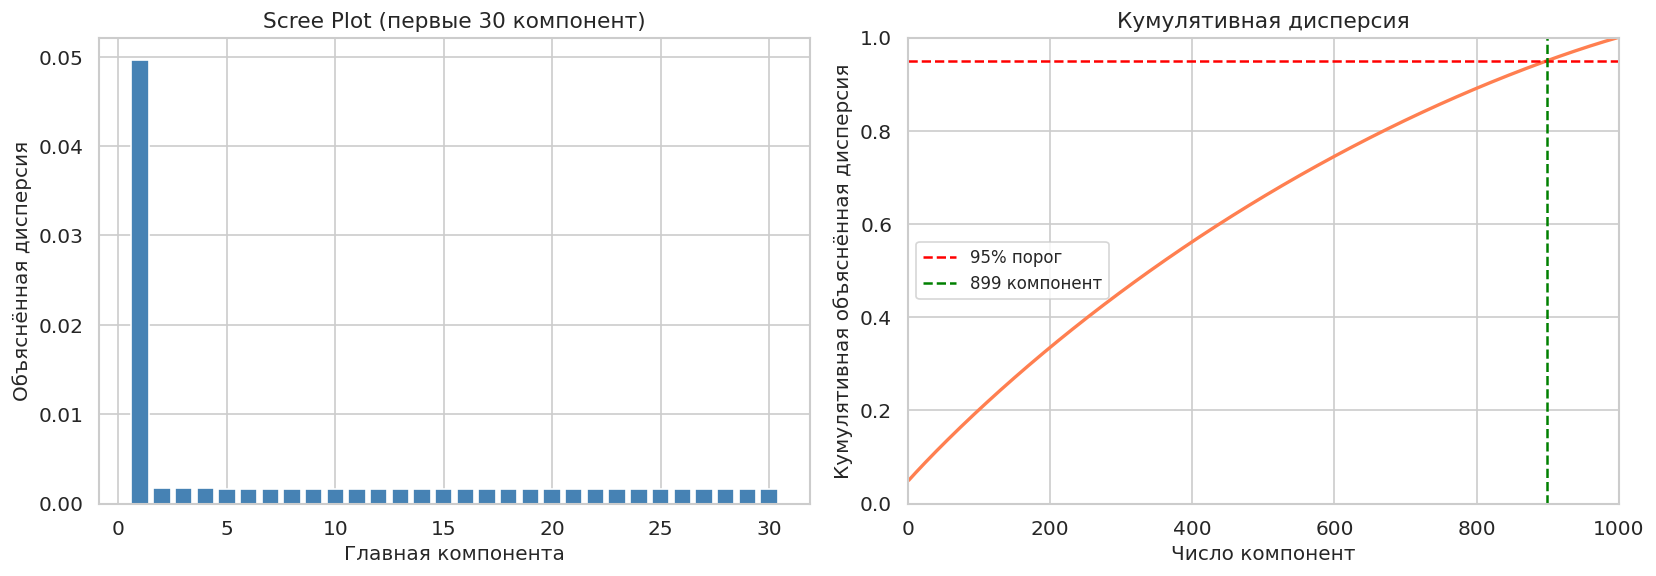

In [4]:
# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Левый график: первые 30 компонент
n_show = 30
axes[0].bar(range(1, n_show + 1), explained_var_ratio[:n_show], color="steelblue", edgecolor="white")
axes[0].set_xlabel("Главная компонента", fontsize=12)
axes[0].set_ylabel("Объяснённая дисперсия", fontsize=12)
axes[0].set_title("Scree Plot (первые 30 компонент)", fontsize=13)

# Правый график: кумулятивная дисперсия
axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var, color="coral", linewidth=2)
axes[1].axhline(0.95, color="red", linestyle="--", linewidth=1.5, label="95% порог")
axes[1].axvline(n_95, color="green", linestyle="--", linewidth=1.5, label=f"{n_95} компонент")
axes[1].set_xlabel("Число компонент", fontsize=12)
axes[1].set_ylabel("Кумулятивная объяснённая дисперсия", fontsize=12)
axes[1].set_title("Кумулятивная дисперсия", fontsize=13)
axes[1].legend(fontsize=10)
axes[1].set_xlim(0, min(1000, len(cumulative_var)))
axes[1].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

## 4. Нелинейное снижение размерности: t-SNE и UMAP

Использование **первых 20 PC** как входа для t-SNE/UMAP - стандартная практика [2].
Это убирает шум из 10 000 SNP и ускоряет вычисления.

### t-SNE (t-distributed Stochastic Neighbor Embedding)

t-SNE переводит попарные расстояния в высокоразмерном пространстве в вероятности через гауссово ядро.
Ширина ядра подбирается автоматически под параметр *perplexity* - сглаженную меру числа эффективных соседей
(типичный диапазон 5-50). В целевом 2D-пространстве аналогичное распределение строится на основе
**t-Стьюдента с одной степенью свободы** (распределение Коши). Его тяжёлые хвосты решают
"проблему скученности": в 2D не хватает объёма, чтобы одновременно сохранить близкие и далёкие пары,
а t-распределение позволяет далёким точкам разойтись. Алгоритм минимизирует KL-дивергенцию между
двумя распределениями градиентным спуском.

| | Плюсы | Минусы |
|---|-------|--------|
| | Чёткие локальные кластеры | Расстояния и размеры кластеров не несут метрического смысла |
| | Адаптивная ширина ядра | Сложность O(n^2) по времени и памяти |
| | | Не сохраняет глобальную структуру |

### UMAP (Uniform Manifold Approximation and Projection)

UMAP моделирует данные как точки, равномерно распределённые на римановом многообразии.
Строит взвешенный k-NN граф в исходном пространстве и аналогичный граф в целевом,
затем минимизирует **бинарную кросс-энтропию** между ними через SGD.
Кросс-энтропия содержит притягивающие и отталкивающие слагаемые - это даёт лучшее
сохранение глобальной структуры по сравнению с KL-дивергенцией t-SNE.

| Параметр | Что делает |
|----------|-----------|
| `n_neighbors` | Масштаб структуры: малые -> локальные кластеры, большие -> глобальная геометрия |
| `min_dist` | Минимальное расстояние между точками: меньше -> плотнее кластеры, больше -> лучше разделение |


| | Плюсы | Минусы |
|---|-------|--------|
| | Сложность O(n log n), масштабируется | Чувствителен к гиперпараметрам и инициализации |
| | Сохраняет глобальную структуру лучше t-SNE | Допущение о равномерности на многообразии не всегда верно |
| | Поддерживает произвольные метрики | Стохастичность - результаты варьируются между запусками |

> [2] Belkina et al., Nature Immunology (2019) - UMAP/t-SNE best practices for cytometry
> McInnes et al., JOSS (2018) - UMAP: Uniform Manifold Approximation and Projection

In [5]:
# --- t-SNE ---
print("Запуск t-SNE (может занять 1-2 минуты)...")
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42,
    n_jobs=-1,
)
X_tsne = tsne.fit_transform(X_pca_20)
print("t-SNE завершён.")

# --- UMAP ---
print("Запуск UMAP...")
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42,
)
X_umap = umap_model.fit_transform(X_pca_20)
print("UMAP завершён.")

Запуск t-SNE (может занять 1-2 минуты)...
t-SNE завершён.
Запуск UMAP...


/home/vadim/work/projects/genomic-ml-playground/genotype_dim_reduction/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP завершён.


## 5. Визуализация: Дашборд PCA / t-SNE / UMAP

Три графика в ряд. Если породы образуют чёткие кластеры - это свидетельствует
о выраженной популяционной структуре в данных.

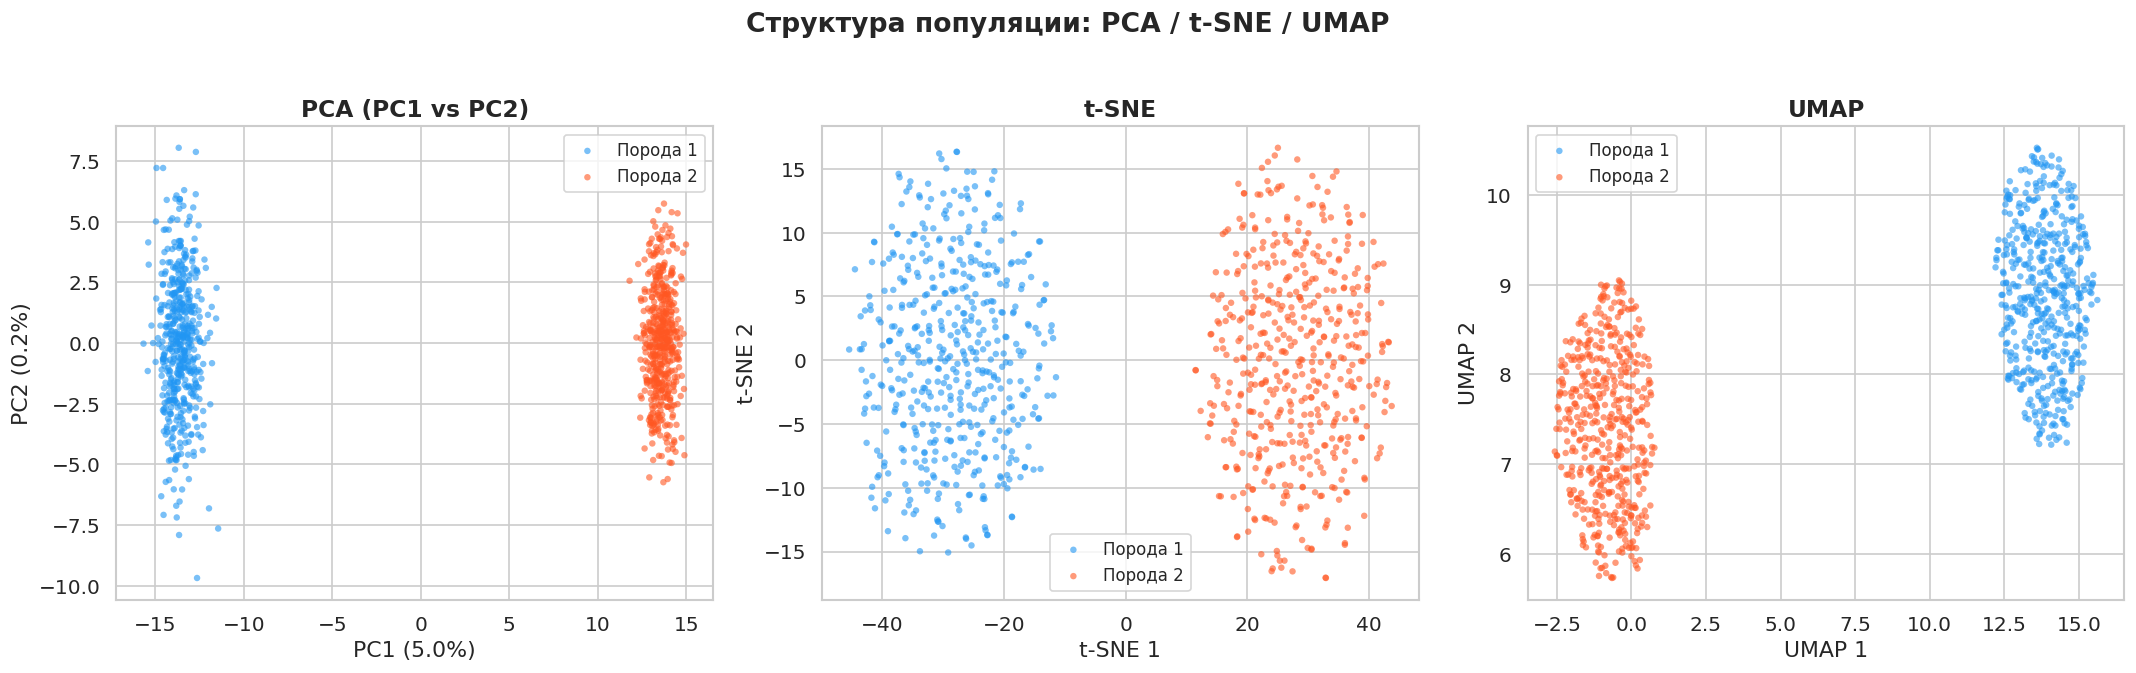

In [6]:
pop_labels = np.where(y == 0, "Порода 1", "Порода 2")
palette = {"Порода 1": "#2196F3", "Порода 2": "#FF5722"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# --- PCA ---
for pop, color in palette.items():
    mask = pop_labels == pop
    axes[0].scatter(
        X_pca_20[mask, 0], X_pca_20[mask, 1],
        c=color, label=pop, alpha=0.6, s=15, edgecolors="none",
    )
axes[0].set_title("PCA (PC1 vs PC2)", fontsize=14, fontweight="bold")
axes[0].set_xlabel(f"PC1 ({explained_var_ratio[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({explained_var_ratio[1]*100:.1f}%)")
axes[0].legend(fontsize=10)

# --- t-SNE ---
for pop, color in palette.items():
    mask = pop_labels == pop
    axes[1].scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=color, label=pop, alpha=0.6, s=15, edgecolors="none",
    )
axes[1].set_title("t-SNE", fontsize=14, fontweight="bold")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].legend(fontsize=10)

# --- UMAP ---
for pop, color in palette.items():
    mask = pop_labels == pop
    axes[2].scatter(
        X_umap[mask, 0], X_umap[mask, 1],
        c=color, label=pop, alpha=0.6, s=15, edgecolors="none",
    )
axes[2].set_title("UMAP", fontsize=14, fontweight="bold")
axes[2].set_xlabel("UMAP 1")
axes[2].set_ylabel("UMAP 2")
axes[2].legend(fontsize=10)

plt.suptitle("Структура популяции: PCA / t-SNE / UMAP", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 6. Выводы

1. **PCA** эффективно разделяет две популяции уже по первой главной компоненте (PC1), что отражает различия в частотах аллелей.
2. **t-SNE** и **UMAP**, применённые к первым 20 PC, подтверждают наличие двух чётких кластеров.
3. Использование PCA как предобработки для нелинейных методов - лучшая практика: это убирает шум из 10,000 SNP и значительно ускоряет вычисления.

Данный пайплайн воспроизводим на реальных генотипических данных (например, VCF -> PLINK -> матрица дозировок).